## Cross-Dataset Generalization Test
Tests all three trained hybrid pipelines (garbage, household, trashnet) on the RealWaste dataset. No training — inference only.

In [1]:
import os, gc, joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 400
BATCH_SIZE = 32
IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD  = [0.229, 0.224, 0.225]

MODELS_DIR  = "/kaggle/input/datasets/darrylmatthew/waste-trained-models"
REALWASTE_PATH = "/kaggle/input/datasets/joebeachcapital/realwaste/realwaste-main/RealWaste"
RESULTS_DIR = "/kaggle/working"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("DEVICE:", DEVICE)
print("RealWaste path exists:", os.path.exists(REALWASTE_PATH))
print("Models available:", sorted(os.listdir(MODELS_DIR)))

DEVICE: cuda
RealWaste path exists: True
Models available: ['custom_resnet50_garbage.pt', 'custom_resnet50_household.pt', 'custom_resnet50_trashnet.pt', 'efficientnet_v2s_garbage.pt', 'efficientnet_v2s_household.pt', 'efficientnet_v2s_trashnet.pt', 'hybrid_pipeline_garbage.joblib', 'hybrid_pipeline_household.joblib', 'hybrid_pipeline_trashnet.joblib']


### Model & Dataset Definitions
Must match the training notebook exactly.

In [2]:
import torchvision.models as tv_models

class CustomResNet50(nn.Module):
    def __init__(self, num_classes, pretrained=False):
        super().__init__()
        w = tv_models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        base = tv_models.resnet50(weights=w)
        self.backbone   = nn.Sequential(*list(base.children())[:-1])
        self.classifier = nn.Linear(2048, num_classes)

    def forward_features(self, x):
        return self.backbone(x).flatten(1)

    def forward(self, x):
        return self.classifier(self.forward_features(x))

class WasteDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.classes   = sorted([d for d in os.listdir(root)
                                  if os.path.isdir(os.path.join(root, d))])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            cls_dir = os.path.join(root, cls)
            for f in os.listdir(cls_dir):
                if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp")):
                    self.samples.append((os.path.join(cls_dir, f),
                                         self.class_to_idx[cls]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

def get_eval_transforms():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGE_MEAN, IMAGE_STD),
    ])

@torch.no_grad()
def extract_deep_features(backbone, loader):
    backbone.eval(); backbone.to(DEVICE)
    features, labels = [], []
    for imgs, lbls in tqdm(loader, desc="Extracting features"):
        feats = backbone.forward_features(imgs.to(DEVICE)).cpu().numpy()
        features.append(feats); labels.extend(lbls.numpy())
    return np.vstack(features), np.array(labels)

print("Definitions ready.")

Definitions ready.


### Load RealWaste Dataset

In [3]:
new_ds     = WasteDataset(REALWASTE_PATH, transform=get_eval_transforms())
new_loader = DataLoader(new_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
new_classes = new_ds.classes
print(f"RealWaste: {len(new_ds)} images, {len(new_classes)} classes")
print("Classes:", new_classes)

RealWaste: 4752 images, 9 classes
Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


### Run Cross-Dataset Test (all 3 trained pipelines)

In [4]:
cross_results = []

from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin

class RFFeatureSelector:
    def __init__(self, top_k=100):
        self.top_k = top_k
        self.rf    = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        self.idx_  = None

    def fit(self, X, y):
        self.rf.fit(X, y)
        self.idx_ = np.argsort(self.rf.feature_importances_)[::-1][:self.top_k]
        return self

    def transform(self, X): return X[:, self.idx_]
    def fit_transform(self, X, y): return self.fit(X, y).transform(X)

print("RFFeatureSelector defined.")

for trained_on in ["garbage", "household", "trashnet"]:
    bundle_path = os.path.join(MODELS_DIR, f"hybrid_pipeline_{trained_on}.joblib")
    pt_path     = os.path.join(MODELS_DIR, f"custom_resnet50_{trained_on}.pt")

    if not os.path.exists(bundle_path) or not os.path.exists(pt_path):
        print(f"[SKIP] {trained_on} — files not found")
        continue

    print(f"\n{'='*55}")
    print(f"Testing: {trained_on} model -> RealWaste")
    print(f"{'='*55}")

    # Load pipeline
    bundle = joblib.load(bundle_path)
    scaler_c, selector_c, clf_c = bundle["scaler"], bundle["selector"], bundle["classifier"]
    train_classes = bundle["classes"]
    print(f"Trained on {len(train_classes)} classes: {train_classes}")

    # Load backbone
    backbone = CustomResNet50(num_classes=len(train_classes), pretrained=False)
    backbone.load_state_dict(torch.load(pt_path, map_location=DEVICE))
    backbone.to(DEVICE).eval()

    # Extract features
    X_new, y_new_local = extract_deep_features(backbone, new_loader)

    # Transform through frozen pipeline
    X_new_s   = scaler_c.transform(X_new)
    X_new_sel = selector_c.transform(X_new_s)
    pred_idx  = clf_c.predict(X_new_sel)

    # Map indices to class names
    pred_names = [train_classes[p] for p in pred_idx]
    true_names = [new_classes[t]   for t in y_new_local]

    # Score only on shared classes (case-insensitive match)
    train_lookup = {c.lower() for c in train_classes}
    keep   = [i for i, t in enumerate(true_names) if t.lower() in train_lookup]
    y_true = [true_names[i].lower() for i in keep]
    y_pred = [pred_names[i].lower() for i in keep]

    shared  = sorted({t for t in y_true})
    acc     = sum(a == b for a, b in zip(y_true, y_pred)) / max(len(y_true), 1) * 100

    print(f"Shared classes ({len(shared)}): {shared}")
    print(f"Images scored : {len(keep)} / {len(new_ds)}")
    print(f"Accuracy      : {acc:.2f}%")

    cross_results.append({
        "trained_on"    : trained_on,
        "tested_on"     : "realwaste",
        "shared_classes": len(shared),
        "n_images"      : len(keep),
        "accuracy"      : round(acc, 2),
        "clf_name"      : bundle.get("clf_name", "unknown"),
    })

    # Free GPU before next pipeline
    del backbone; gc.collect(); torch.cuda.empty_cache()

print("\nDone.")

RFFeatureSelector defined.

Testing: garbage model -> RealWaste
Trained on 10 classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


Extracting features: 100%|██████████| 149/149 [00:57<00:00,  2.59it/s]


Shared classes (5): ['cardboard', 'glass', 'metal', 'paper', 'plastic']
Images scored : 3092 / 4752
Accuracy      : 50.71%

Testing: household model -> RealWaste
Trained on 12 classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


Extracting features: 100%|██████████| 149/149 [00:48<00:00,  3.05it/s]


Shared classes (4): ['cardboard', 'metal', 'paper', 'plastic']
Images scored : 2672 / 4752
Accuracy      : 47.23%

Testing: trashnet model -> RealWaste
Trained on 6 classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


Extracting features: 100%|██████████| 149/149 [00:52<00:00,  2.83it/s]


Shared classes (5): ['cardboard', 'glass', 'metal', 'paper', 'plastic']
Images scored : 3092 / 4752
Accuracy      : 43.60%

Done.


### Summary Table & Save

In [5]:
df_cross = pd.DataFrame(cross_results)
print("\nCross-dataset generalization results:")
print(df_cross.to_string(index=False))

out_path = os.path.join(RESULTS_DIR, "cross_dataset_realwaste.csv")
df_cross.to_csv(out_path, index=False)
print(f"\nSaved -> {out_path}")


Cross-dataset generalization results:
trained_on tested_on  shared_classes  n_images  accuracy clf_name
   garbage realwaste               5      3092     50.71      LoR
 household realwaste               4      2672     47.23      LoR
  trashnet realwaste               5      3092     43.60      LoR

Saved -> /kaggle/working/cross_dataset_realwaste.csv


Extracting features: 100%|██████████| 149/149 [00:53<00:00,  2.78it/s]



Trained on: garbage | Shared classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic']
              precision    recall  f1-score   support

   cardboard      0.690     0.150     0.246       461
       glass      0.458     0.419     0.438       420
       metal      0.702     0.752     0.726       790
       paper      0.466     0.766     0.579       500
     plastic      0.680     0.376     0.484       921

   micro avg      0.589     0.507     0.545      3092
   macro avg      0.599     0.492     0.495      3092
weighted avg      0.622     0.507     0.520      3092



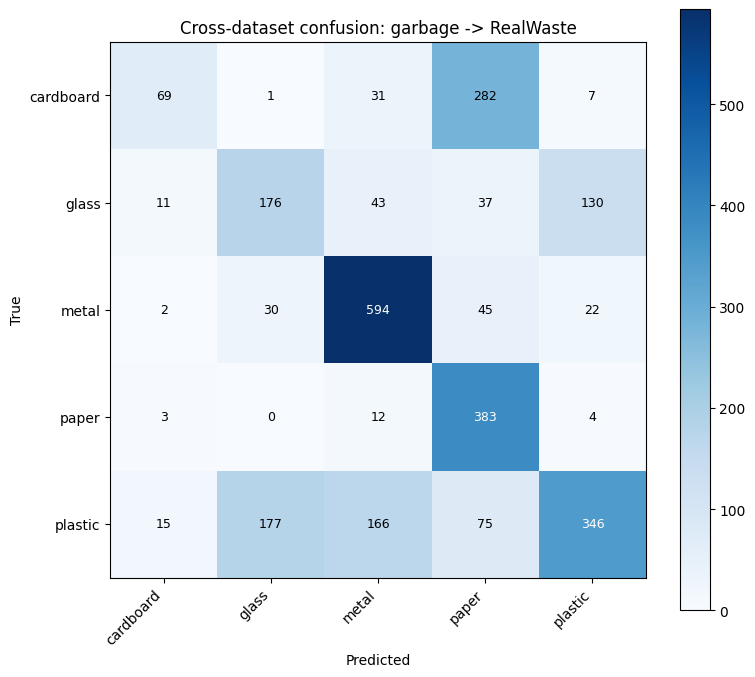

Extracting features: 100%|██████████| 149/149 [00:53<00:00,  2.80it/s]



Trained on: household | Shared classes: ['cardboard', 'metal', 'paper', 'plastic']
              precision    recall  f1-score   support

   cardboard      0.697     0.434     0.535       461
       metal      0.811     0.637     0.713       790
       paper      0.513     0.368     0.428       500
     plastic      0.833     0.407     0.547       921

   micro avg      0.735     0.472     0.575      2672
   macro avg      0.714     0.461     0.556      2672
weighted avg      0.743     0.472     0.572      2672



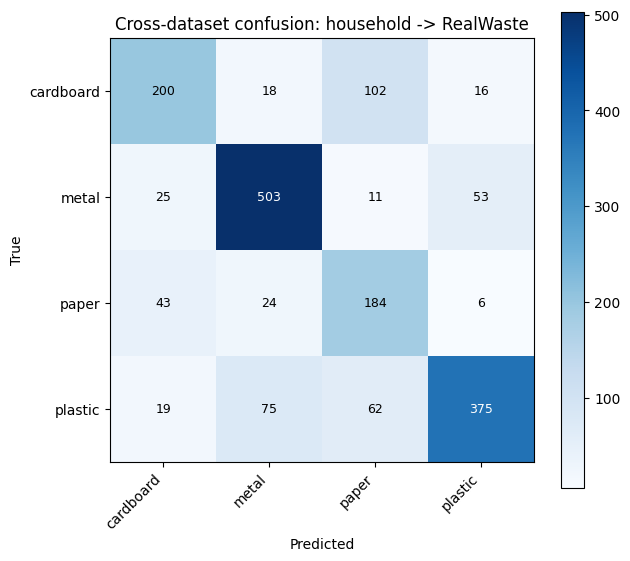

Extracting features: 100%|██████████| 149/149 [00:53<00:00,  2.81it/s]



Trained on: trashnet | Shared classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic']
              precision    recall  f1-score   support

   cardboard      0.319     0.540     0.401       461
       glass      0.807     0.110     0.193       420
       metal      0.768     0.609     0.679       790
       paper      0.427     0.414     0.420       500
     plastic      0.647     0.396     0.492       921

   micro avg      0.537     0.436     0.481      3092
   macro avg      0.594     0.414     0.437      3092
weighted avg      0.615     0.436     0.474      3092



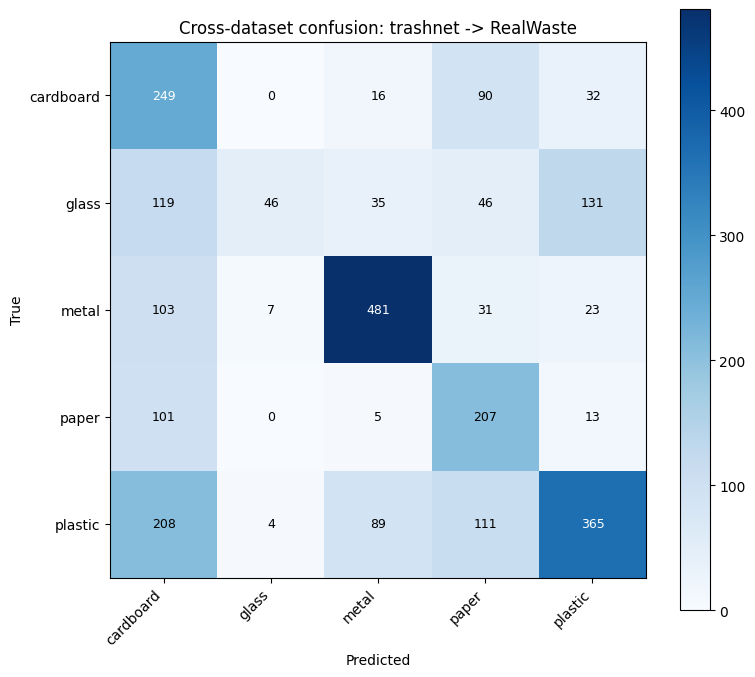

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

for trained_on in ["garbage", "household", "trashnet"]:
    bundle_path = os.path.join(MODELS_DIR, f"hybrid_pipeline_{trained_on}.joblib")
    pt_path     = os.path.join(MODELS_DIR, f"custom_resnet50_{trained_on}.pt")
    if not os.path.exists(bundle_path): continue

    bundle = joblib.load(bundle_path)
    scaler_c, selector_c, clf_c = bundle["scaler"], bundle["selector"], bundle["classifier"]
    train_classes = bundle["classes"]

    backbone = CustomResNet50(num_classes=len(train_classes), pretrained=False)
    backbone.load_state_dict(torch.load(pt_path, map_location=DEVICE))
    backbone.to(DEVICE).eval()

    X_new, y_new_local = extract_deep_features(backbone, new_loader)
    X_new_sel = selector_c.transform(scaler_c.transform(X_new))
    pred_idx  = clf_c.predict(X_new_sel)

    pred_names = [train_classes[p] for p in pred_idx]
    true_names = [new_classes[t]   for t in y_new_local]

    train_lookup = {c.lower() for c in train_classes}
    keep   = [i for i, t in enumerate(true_names) if t.lower() in train_lookup]
    y_true = [true_names[i].lower() for i in keep]
    y_pred = [pred_names[i].lower() for i in keep]
    shared = sorted({t for t in y_true})

    # Per-class accuracy
    print(f"\n{'='*50}")
    print(f"Trained on: {trained_on} | Shared classes: {shared}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, labels=shared,
                                target_names=shared, digits=3, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=shared)
    fig, ax = plt.subplots(figsize=(len(shared)*1.4+1, len(shared)*1.2+1))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(shared))); ax.set_xticklabels(shared, rotation=45, ha="right")
    ax.set_yticks(range(len(shared))); ax.set_yticklabels(shared)
    thresh = cm.max() / 2
    for r in range(len(shared)):
        for c in range(len(shared)):
            ax.text(c, r, cm[r,c], ha="center", va="center", fontsize=9,
                    color="white" if cm[r,c] > thresh else "black")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Cross-dataset confusion: {trained_on} -> RealWaste")
    plt.colorbar(im); plt.tight_layout(); plt.show()

    del backbone; gc.collect(); torch.cuda.empty_cache()

In [11]:
import os, gc, joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
import torchvision.models as tv_models
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 400
BATCH_SIZE = 32
IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD  = [0.229, 0.224, 0.225]
FINETUNE_EPOCHS = 10
FINETUNE_LR     = 1e-4
RANDOM_SEED     = 42

MODELS_DIR     = "/kaggle/input/datasets/darrylmatthew/waste-trained-models"
REALWASTE_PATH = "/kaggle/input/datasets/joebeachcapital/realwaste/realwaste-main/RealWaste"
RESULTS_DIR    = "/kaggle/working"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("DEVICE:", DEVICE)

DEVICE: cuda


In [13]:
class CustomResNet50(nn.Module):
    def __init__(self, num_classes, pretrained=False):
        super().__init__()
        w = tv_models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        base = tv_models.resnet50(weights=w)
        self.backbone   = nn.Sequential(*list(base.children())[:-1])
        self.classifier = nn.Linear(2048, num_classes)
    def forward_features(self, x):
        return self.backbone(x).flatten(1)
    def forward(self, x):
        return self.classifier(self.forward_features(x))

class WasteDataset(Dataset):
    def __init__(self, root, shared_classes=None, transform=None):
        """If shared_classes given, only load those class folders (case-insensitive)."""
        self.transform = transform
        all_dirs = sorted([d for d in os.listdir(root)
                           if os.path.isdir(os.path.join(root, d))])
        if shared_classes:
            keep = {c.lower() for c in shared_classes}
            all_dirs = [d for d in all_dirs if d.lower() in keep]
        self.classes = all_dirs
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            for f in os.listdir(os.path.join(root, cls)):
                if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp")):
                    self.samples.append(
                        (os.path.join(root, cls, f), self.class_to_idx[cls]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

def get_eval_transforms():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGE_MEAN, IMAGE_STD),
    ])

def get_train_transforms():
    return transforms.Compose([
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGE_MEAN, IMAGE_STD),
    ])

@torch.no_grad()
def test_accuracy(model, loader):
    model.eval(); model.to(DEVICE)
    correct, total = 0, 0
    for imgs, labels in loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        correct += (preds == labels).sum().item()
        total   += len(labels)
    return round(correct / max(total,1) * 100, 2)

print("Definitions ready.")

Definitions ready.



  GARBAGE -> RealWaste  |  5 shared: ['cardboard', 'glass', 'metal', 'paper', 'plastic']
Zero-shot accuracy (holdout): 62.36%


  Epoch  1 | train: 81.68% | val: 92.73%


  Epoch  2 | train: 92.44% | val: 93.70%


  Epoch  3 | train: 95.23% | val: 92.08%


  Epoch  4 | train: 97.09% | val: 93.70%


...

  Epoch  6 | train: 98.14% | val: 93.54%


  Epoch  7 | train: 98.34% | val: 95.80%


  Epoch  8 | train: 98.83% | val: 93.38%


  Epoch  9 | train: 98.50% | val: 93.54%


  Epoch 10 | train: 99.47% | val: 95.48%

Fine-tuned accuracy (holdout): 95.48%  |  improvement: +33.12%


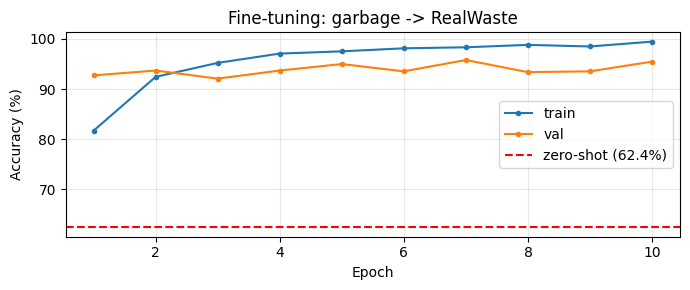

              precision    recall  f1-score   support

   cardboard      0.968     0.978     0.973        92
       glass      0.975     0.929     0.951        84
       metal      0.921     0.962     0.941       158
       paper      0.990     0.960     0.975       100
     plastic      0.951     0.946     0.949       185

    accuracy                          0.955       619
   macro avg      0.961     0.955     0.958       619
weighted avg      0.955     0.955     0.955       619


  HOUSEHOLD -> RealWaste  |  4 shared: ['cardboard', 'metal', 'paper', 'plastic']
Zero-shot accuracy (holdout): 68.79%


  Epoch  1 | train: 81.80% | val: 92.52%


  Epoch  2 | train: 93.64% | val: 92.34%


  Epoch  3 | train: 95.46% | val: 91.59%


  Epoch  4 | train: 95.93% | val: 93.46%


...

  Epoch  6 | train: 98.13% | val: 94.95%


  Epoch  7 | train: 98.36% | val: 91.03%


  Epoch  8 | train: 98.18% | val: 95.14%


  Epoch  9 | train: 98.92% | val: 94.77%


  Epoch 10 | train: 98.92% | val: 95.70%

Fine-tuned accuracy (holdout): 95.70%  |  improvement: +26.92%


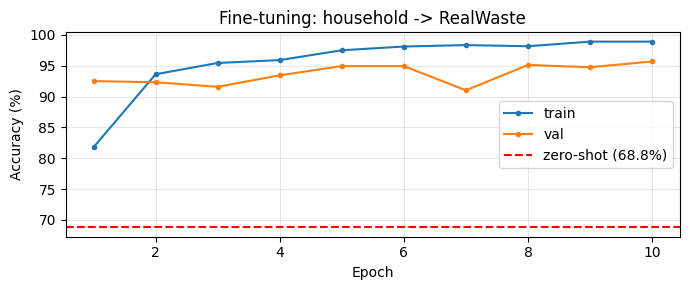

              precision    recall  f1-score   support

   cardboard      0.966     0.935     0.950        92
       metal      0.993     0.911     0.950       158
       paper      0.970     0.980     0.975       100
     plastic      0.920     0.995     0.956       185

    accuracy                          0.957       535
   macro avg      0.962     0.955     0.958       535
weighted avg      0.959     0.957     0.957       535


  TRASHNET -> RealWaste  |  5 shared: ['cardboard', 'glass', 'metal', 'paper', 'plastic']
Zero-shot accuracy (holdout): 55.74%


  Epoch  1 | train: 80.91% | val: 89.82%


  Epoch  2 | train: 91.71% | val: 92.25%


  Epoch  3 | train: 94.66% | val: 93.38%


  Epoch  4 | train: 96.89% | val: 95.48%


...

  Epoch  6 | train: 97.70% | val: 95.48%


  Epoch  7 | train: 98.87% | val: 95.80%


  Epoch  8 | train: 98.34% | val: 93.54%


  Epoch  9 | train: 98.63% | val: 94.99%


  Epoch 10 | train: 99.07% | val: 95.96%

Fine-tuned accuracy (holdout): 95.96%  |  improvement: +40.23%


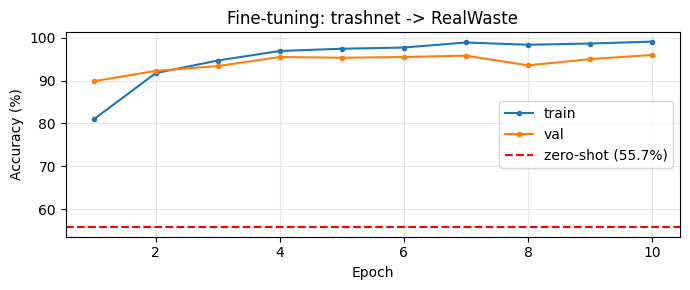

              precision    recall  f1-score   support

   cardboard      0.926     0.946     0.935        92
       glass      0.932     0.976     0.953        84
       metal      0.974     0.956     0.965       158
       paper      0.990     0.950     0.969       100
     plastic      0.962     0.968     0.965       185

    accuracy                          0.960       619
   macro avg      0.957     0.959     0.958       619
weighted avg      0.960     0.960     0.960       619


All fine-tuning done.


In [14]:
SHARED = {
    "garbage"  : ["cardboard","glass","metal","paper","plastic"],
    "household": ["cardboard","metal","paper","plastic"],
    "trashnet" : ["cardboard","glass","metal","paper","plastic"],
}

finetune_results = []

for trained_on, shared_classes in SHARED.items():
    pt_path = os.path.join(MODELS_DIR, f"custom_resnet50_{trained_on}.pt")
    if not os.path.exists(pt_path):
        print(f"[SKIP] {trained_on} — .pt not found"); continue

    n_shared = len(shared_classes)
    print(f"\n{'='*58}")
    print(f"  {trained_on.upper()} -> RealWaste  |  {n_shared} shared: {shared_classes}")
    print(f"{'='*58}")

    # Filtered RealWaste dataset and 80/20 split
    full_ds = WasteDataset(REALWASTE_PATH, shared_classes=shared_classes,
                           transform=get_eval_transforms())
    labels_all = [s[1] for s in full_ds.samples]
    train_idx, test_idx = train_test_split(
        range(len(full_ds)), test_size=0.2,
        random_state=RANDOM_SEED, stratify=labels_all)

    test_ds     = Subset(full_ds, test_idx)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    shared_sorted = sorted(c.lower() for c in shared_classes)

    # Zero-shot on holdout using original backbone logits subset
    orig_n = {"garbage":10,"household":12,"trashnet":6}[trained_on]
    bundle = joblib.load(os.path.join(MODELS_DIR, f"hybrid_pipeline_{trained_on}.joblib"))
    train_classes = bundle["classes"]
    train_lookup  = {c.lower(): i for i, c in enumerate(train_classes)}

    orig_model = CustomResNet50(num_classes=orig_n, pretrained=False)
    orig_model.load_state_dict(torch.load(pt_path, map_location=DEVICE))
    orig_model.to(DEVICE).eval()

    y_true_zs, y_pred_zs = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            logits = orig_model(imgs.to(DEVICE)).cpu()
            shared_indices = [train_lookup[c] for c in shared_sorted if c in train_lookup]
            preds = logits[:, shared_indices].argmax(1).numpy()
            y_pred_zs.extend(preds); y_true_zs.extend(lbls.numpy())

    zs_acc = sum(a==b for a,b in zip(y_true_zs,y_pred_zs))/max(len(y_true_zs),1)*100
    print(f"Zero-shot accuracy (holdout): {zs_acc:.2f}%")
    del orig_model; gc.collect(); torch.cuda.empty_cache()

    # Fine-tune train loader with augmentation
    train_ds_aug = WasteDataset(REALWASTE_PATH, shared_classes=shared_classes,
                                transform=get_train_transforms())
    train_loader = DataLoader(Subset(train_ds_aug, train_idx),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)

    # Load backbone, replace head, freeze conv1-layer2
    ft_model = CustomResNet50(num_classes=orig_n, pretrained=False)
    ft_model.load_state_dict(torch.load(pt_path, map_location=DEVICE))
    ft_model.classifier = nn.Linear(2048, n_shared)
    for i, child in enumerate(ft_model.backbone.children()):
        for param in child.parameters():
            param.requires_grad = (i >= 6)   # train layer3, layer4 only

    ft_model.to(DEVICE)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, ft_model.parameters()), lr=FINETUNE_LR)
    criterion = nn.CrossEntropyLoss()

    history = []
    for epoch in range(1, FINETUNE_EPOCHS+1):
        ft_model.train()
        correct, total = 0, 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{FINETUNE_EPOCHS}", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = ft_model(imgs)
            loss = criterion(logits, labels)
            loss.backward(); optimizer.step()
            correct += (logits.argmax(1)==labels).sum().item()
            total   += len(labels)
        ft_model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                preds = ft_model(imgs.to(DEVICE)).argmax(1).cpu()
                val_correct += (preds==labels).sum().item()
                val_total   += len(labels)
        val_acc = val_correct/val_total*100
        print(f"  Epoch {epoch:2d} | train: {correct/total*100:.2f}% | val: {val_acc:.2f}%")
        history.append({"epoch":epoch,"train_acc":correct/total*100,"val_acc":val_acc})

    ft_acc = history[-1]["val_acc"]
    print(f"\nFine-tuned accuracy (holdout): {ft_acc:.2f}%  |  improvement: +{ft_acc-zs_acc:.2f}%")

    # Training curve
    df_h = pd.DataFrame(history)
    plt.figure(figsize=(7,3))
    plt.plot(df_h["epoch"], df_h["train_acc"], label="train", marker="o", markersize=3)
    plt.plot(df_h["epoch"], df_h["val_acc"],   label="val",   marker="o", markersize=3)
    plt.axhline(zs_acc, color="red", linestyle="--", label=f"zero-shot ({zs_acc:.1f}%)")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
    plt.title(f"Fine-tuning: {trained_on} -> RealWaste")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # Per-class report
    all_true, all_pred = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            preds = ft_model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
            all_pred.extend(preds); all_true.extend(lbls.numpy())
    print(classification_report(all_true, all_pred,
                                target_names=shared_sorted, digits=3, zero_division=0))

    torch.save(ft_model.state_dict(),
               os.path.join(RESULTS_DIR, f"finetuned_{trained_on}_realwaste.pt"))
    finetune_results.append({
        "trained_on"    : trained_on,
        "shared_classes": n_shared,
        "zero_shot_acc" : round(zs_acc, 2),
        "finetuned_acc" : round(ft_acc, 2),
        "improvement"   : round(ft_acc - zs_acc, 2),
    })
    del ft_model; gc.collect(); torch.cuda.empty_cache()

print("\nAll fine-tuning done.")


Fine-tuning summary:
trained_on  shared_classes  zero_shot_acc  finetuned_acc  improvement
   garbage               5          62.36          95.48        33.12
 household               4          68.79          95.70        26.92
  trashnet               5          55.74          95.96        40.23


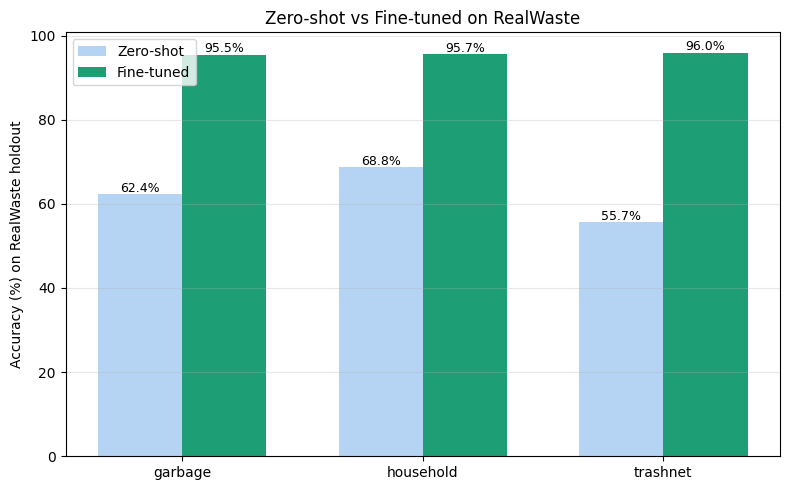

Saved -> /kaggle/working/finetune_realwaste_summary.csv


In [16]:
df_ft = pd.DataFrame(finetune_results)
print("\nFine-tuning summary:")
print(df_ft.to_string(index=False))

# Bar chart: zero-shot vs fine-tuned
x = np.arange(len(df_ft))
w = 0.35
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - w/2, df_ft["zero_shot_acc"], w, label="Zero-shot", color="#B5D4F4")
ax.bar(x + w/2, df_ft["finetuned_acc"], w, label="Fine-tuned", color="#1D9E75")
ax.set_xticks(x); ax.set_xticklabels(df_ft["trained_on"])
ax.set_ylabel("Accuracy (%) on RealWaste holdout")
ax.set_title("Zero-shot vs Fine-tuned on RealWaste")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for i, row in df_ft.iterrows():
    ax.text(i - w/2, row["zero_shot_acc"] + 0.5, f"{row['zero_shot_acc']:.1f}%",
            ha="center", fontsize=9)
    ax.text(i + w/2, row["finetuned_acc"] + 0.5, f"{row['finetuned_acc']:.1f}%",
            ha="center", fontsize=9)
plt.tight_layout(); plt.show()

out = os.path.join(RESULTS_DIR, "finetune_realwaste_summary.csv")
df_ft.to_csv(out, index=False)
print(f"Saved -> {out}")